# KV Caching: Efficient Autoregressive Inference

This notebook explores **KV (Key-Value) Caching**, a crucial optimization technique that makes transformer inference fast and efficient. Without KV caching, generating each new token would require recomputing attention over all previous tokens — a massive waste of computation.

**What you'll learn:**
- Why autoregressive generation is slow without caching
- How KV caching eliminates redundant computation
- Implementing KV caching from scratch
- Memory-speed tradeoffs and cache management
- Multi-Query Attention (MQA) and Grouped-Query Attention (GQA)
- Using KV caching in practice


## Setup


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import time
from aiml_notebooks import get_device, set_seed

# Set style and seed for reproducibility
sns.set_style('whitegrid')
set_seed(42)
device = get_device()


Using MPS (Metal Performance Shaders) for GPU acceleration


## Part 1: The Problem with Autoregressive Generation

### How Transformers Generate Text

Autoregressive models like GPT generate text **one token at a time**:

1. Input: "The cat"
2. Model predicts: "sat"
3. Input: "The cat sat"
4. Model predicts: "on"
5. Input: "The cat sat on"
6. Model predicts: "the"
7. ... and so on

At each step, **the entire sequence is processed** through the transformer. This means:
- At step 1: Process 2 tokens
- At step 2: Process 3 tokens (including the 2 we already processed!)
- At step 3: Process 4 tokens
- At step N: Process N tokens

**The problem**: We keep reprocessing the same tokens over and over!


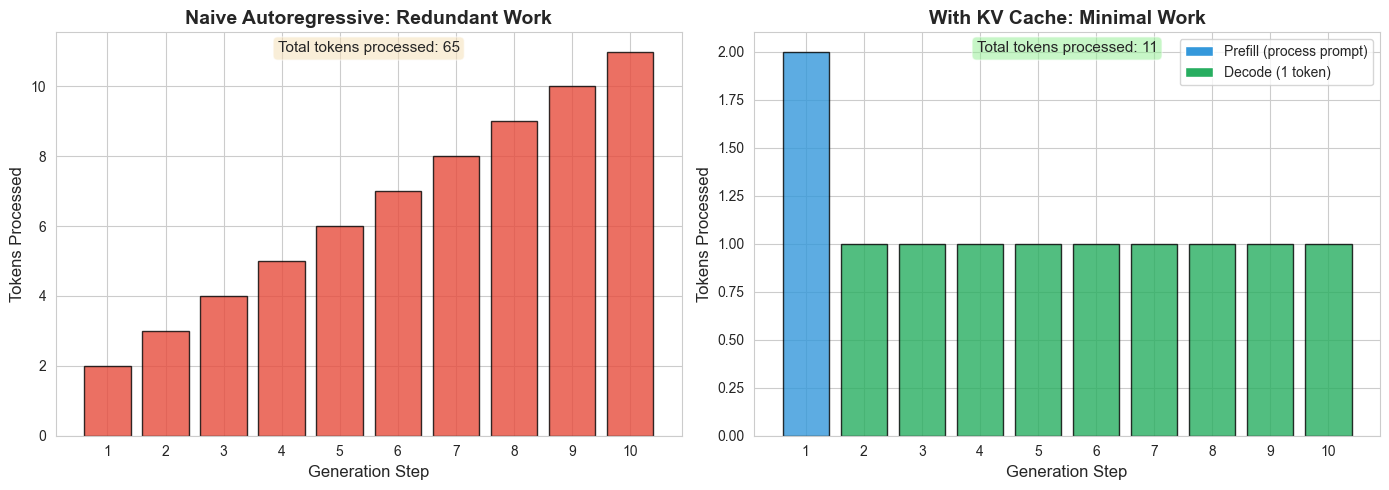

Naive approach: 65 total tokens processed
With KV cache: 11 total tokens processed
Speedup: 5.9x


In [21]:
# Visualize the redundant computation problem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Naive generation - work done at each step
ax1 = axes[0]
steps = range(1, 11)
tokens_processed_naive = [i + 1 for i in steps]  # At step i, process i+1 tokens

ax1.bar(steps, tokens_processed_naive, color='#e74c3c', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Generation Step', fontsize=12)
ax1.set_ylabel('Tokens Processed', fontsize=12)
ax1.set_title('Naive Autoregressive: Redundant Work', fontsize=14, fontweight='bold')
ax1.set_xticks(steps)

# Add cumulative annotation
total_naive = sum(tokens_processed_naive)
ax1.annotate(f'Total tokens processed: {total_naive}', xy=(0.5, 0.95), 
             xycoords='axes fraction', fontsize=11, ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: With KV Cache - work done at each step
ax2 = axes[1]
tokens_processed_cached = [2] + [1] * 9  # First step: 2 tokens, then 1 each

colors = ['#3498db' if i == 0 else '#27ae60' for i in range(len(steps))]
ax2.bar(steps, tokens_processed_cached, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Generation Step', fontsize=12)
ax2.set_ylabel('Tokens Processed', fontsize=12)
ax2.set_title('With KV Cache: Minimal Work', fontsize=14, fontweight='bold')
ax2.set_xticks(steps)

# Add cumulative annotation
total_cached = sum(tokens_processed_cached)
ax2.annotate(f'Total tokens processed: {total_cached}', xy=(0.5, 0.95), 
             xycoords='axes fraction', fontsize=11, ha='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Prefill (process prompt)'),
                   Patch(facecolor='#27ae60', label='Decode (1 token)')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Naive approach: {total_naive} total tokens processed")
print(f"With KV cache: {total_cached} total tokens processed")
print(f"Speedup: {total_naive / total_cached:.1f}x")


### Computational Complexity Analysis

For generating $T$ new tokens from a prompt of length $P$:

| Approach | Computation per Layer | Total for $T$ Tokens |
|----------|----------------------|---------------------|
| **Naive** | $O((P+t)^2 \cdot d)$ for step $t$ | $O(T \cdot (P+T)^2 \cdot d)$ |
| **With KV Cache** | $O(P^2 \cdot d)$ prefill + $O((P+t) \cdot d)$ decode | $O(P^2 \cdot d + T \cdot (P+T) \cdot d)$ |

The KV cache converts **quadratic** decode steps to **linear**!


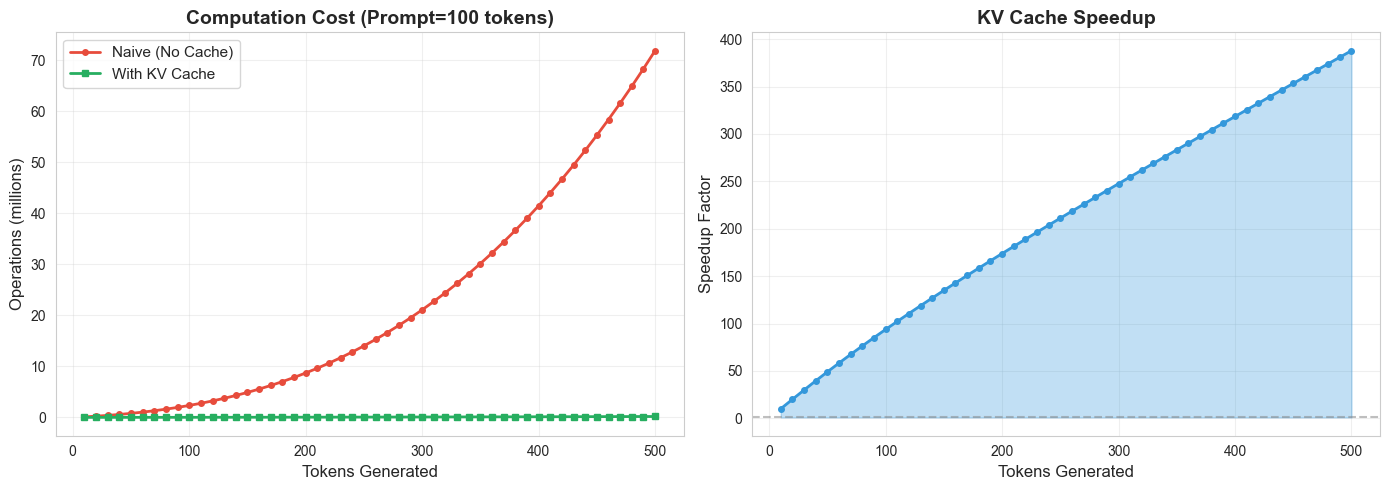

At 100 generated tokens: 93.7x speedup
At 500 generated tokens: 387.8x speedup


In [22]:
# Visualize complexity scaling
prompt_len = 100
gen_lengths = np.arange(10, 510, 10)

def naive_complexity(P, T):
    """Total computation for naive autoregressive generation."""
    return sum((P + t)**2 for t in range(1, T + 1))

def cached_complexity(P, T):
    """Total computation with KV caching."""
    prefill = P**2  # Process prompt once
    decode = sum(P + t for t in range(1, T + 1))  # Linear per step
    return prefill + decode

naive_ops = [naive_complexity(prompt_len, T) for T in gen_lengths]
cached_ops = [cached_complexity(prompt_len, T) for T in gen_lengths]

# Normalize to millions of operations
naive_ops_m = np.array(naive_ops) / 1e6
cached_ops_m = np.array(cached_ops) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Absolute comparison
ax1 = axes[0]
ax1.plot(gen_lengths, naive_ops_m, 'o-', label='Naive (No Cache)', 
         linewidth=2, markersize=4, color='#e74c3c')
ax1.plot(gen_lengths, cached_ops_m, 's-', label='With KV Cache', 
         linewidth=2, markersize=4, color='#27ae60')
ax1.set_xlabel('Tokens Generated', fontsize=12)
ax1.set_ylabel('Operations (millions)', fontsize=12)
ax1.set_title(f'Computation Cost (Prompt={prompt_len} tokens)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Speedup ratio
ax2 = axes[1]
speedup = np.array(naive_ops) / np.array(cached_ops)
ax2.plot(gen_lengths, speedup, 'o-', linewidth=2, markersize=4, color='#3498db')
ax2.fill_between(gen_lengths, 1, speedup, alpha=0.3, color='#3498db')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Tokens Generated', fontsize=12)
ax2.set_ylabel('Speedup Factor', fontsize=12)
ax2.set_title('KV Cache Speedup', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"At 100 generated tokens: {speedup[9]:.1f}x speedup")
print(f"At 500 generated tokens: {speedup[-1]:.1f}x speedup")


## Part 2: How KV Caching Works

### Attention Mechanism Review

Recall the attention computation:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
- $Q = XW_Q$ (queries from input)
- $K = XW_K$ (keys from input)  
- $V = XW_V$ (values from input)

### Key Insight: K and V Do Not Change for Past Tokens

When generating the next token, we only need to compute Q for the **new token**. The K and V for all **previous tokens remain the same**!

This is because:
1. In causal attention, each position only attends to previous positions
2. The K and V projections only depend on the token at that position
3. Past tokens do not change, so their K and V do not change


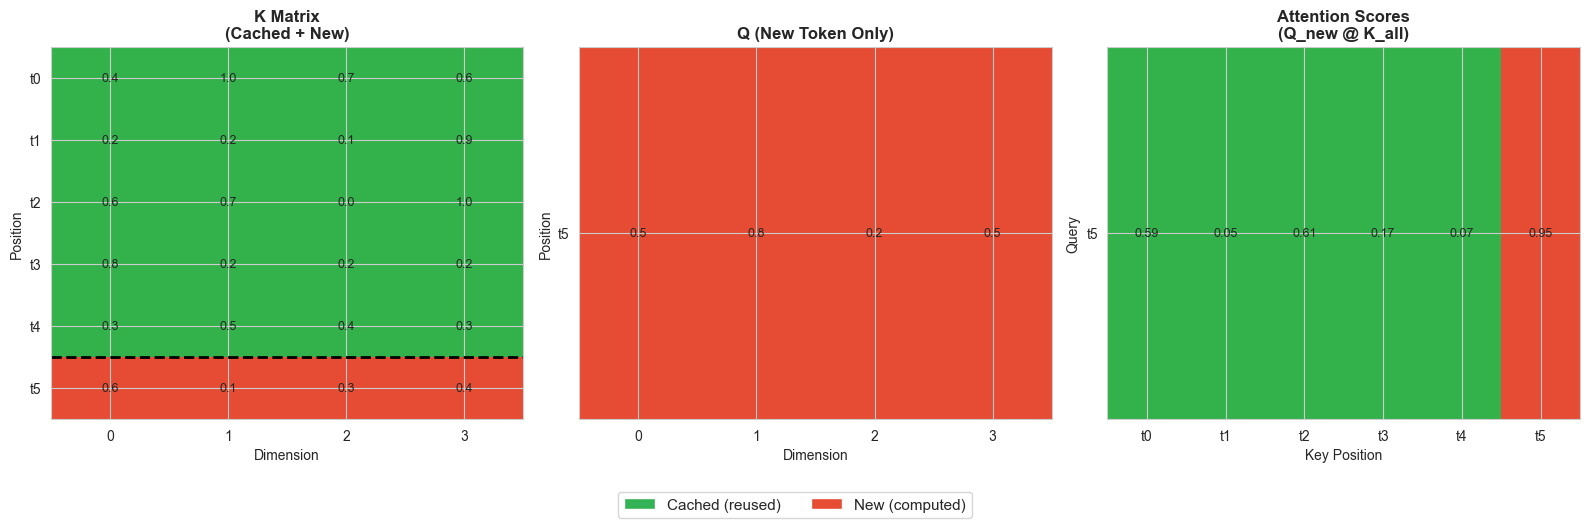

Key insight: Only the red parts need to be computed!
The green parts are retrieved from the KV cache.


In [23]:
# Visualize what gets cached vs recomputed
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

seq_len = 6
d_k = 4

# Helper to create matrix visualization
def draw_matrix(ax, data, title, cmap='Blues', labels=None):
    sns.heatmap(data, ax=ax, cmap=cmap, cbar=False, 
                annot=True, fmt='.1f', annot_kws={'size': 9})
    ax.set_title(title, fontsize=12, fontweight='bold')
    if labels:
        ax.set_xlabel(labels[0])
        ax.set_ylabel(labels[1])

# Scenario: We have 5 cached tokens and are generating token 6
cached_len = 5
new_pos = 5

# Create sample matrices
np.random.seed(42)

# Left: Full sequence K, V (what's in cache + new)
ax1 = axes[0]
k_matrix = np.random.rand(seq_len, d_k)
colors_k = np.zeros((seq_len, d_k, 4))
colors_k[:cached_len, :] = [0.2, 0.7, 0.3, 0.7]  # Green for cached
colors_k[cached_len:, :] = [0.9, 0.3, 0.2, 0.7]   # Red for new

# Create a custom visualization
ax1.imshow(colors_k[:, :, :3], aspect='auto')
for i in range(seq_len):
    for j in range(d_k):
        ax1.text(j, i, f'{k_matrix[i,j]:.1f}', ha='center', va='center', fontsize=9)
ax1.set_title('K Matrix\n(Cached + New)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dimension')
ax1.set_ylabel('Position')
ax1.set_xticks(range(d_k))
ax1.set_yticks(range(seq_len))
ax1.set_yticklabels([f't{i}' for i in range(seq_len)])
ax1.axhline(y=cached_len - 0.5, color='black', linewidth=2, linestyle='--')

# Middle: Query (only new token)
ax2 = axes[1]
q_new = np.random.rand(1, d_k)
colors_q = np.zeros((1, d_k, 4))
colors_q[:, :] = [0.9, 0.3, 0.2, 0.7]  # Red for new
ax2.imshow(colors_q[:, :, :3], aspect='auto')
for j in range(d_k):
    ax2.text(j, 0, f'{q_new[0,j]:.1f}', ha='center', va='center', fontsize=9)
ax2.set_title('Q (New Token Only)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dimension')
ax2.set_ylabel('Position')
ax2.set_xticks(range(d_k))
ax2.set_yticks([0])
ax2.set_yticklabels(['t5'])

# Right: Attention computation
ax3 = axes[2]
# Q_new @ K^T = attention scores for new token
attn_scores = np.random.rand(1, seq_len)
colors_attn = np.zeros((1, seq_len, 4))
colors_attn[:, :cached_len] = [0.2, 0.7, 0.3, 0.7]  # Attending to cached
colors_attn[:, cached_len:] = [0.9, 0.3, 0.2, 0.7]   # Self-attention

ax3.imshow(colors_attn[:, :, :3], aspect='auto')
for j in range(seq_len):
    ax3.text(j, 0, f'{attn_scores[0,j]:.2f}', ha='center', va='center', fontsize=9)
ax3.set_title('Attention Scores\n(Q_new @ K_all)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Key Position')
ax3.set_ylabel('Query')
ax3.set_xticks(range(seq_len))
ax3.set_xticklabels([f't{i}' for i in range(seq_len)])
ax3.set_yticks([0])
ax3.set_yticklabels(['t5'])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#33b355', label='Cached (reused)'),
                   Patch(facecolor='#e64d33', label='New (computed)')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11, 
           bbox_to_anchor=(0.5, 0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

print("Key insight: Only the red parts need to be computed!")
print("The green parts are retrieved from the KV cache.")


## Part 3: Implementing KV Caching from Scratch

Let us implement a simple transformer attention layer with KV caching support.


In [24]:
class CausalSelfAttention(nn.Module):
    """
    Causal self-attention with KV caching support.
    """
    def __init__(self, d_model, n_heads, max_seq_len=512):
        super().__init__()
        assert d_model % n_heads == 0
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.max_seq_len = max_seq_len
        
        # Q, K, V projections
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        
        # Causal mask (lower triangular)
        self.register_buffer(
            'causal_mask',
            torch.tril(torch.ones(max_seq_len, max_seq_len)).view(1, 1, max_seq_len, max_seq_len)
        )
        
    def forward(self, x, kv_cache=None, use_cache=False):
        """
        Forward pass with optional KV caching.
        
        Args:
            x: Input tensor (batch, seq_len, d_model)
               During generation with cache: seq_len = 1 (just the new token)
            kv_cache: Tuple of (cached_k, cached_v) or None
            use_cache: Whether to return updated cache
            
        Returns:
            output: Attention output (batch, seq_len, d_model)
            new_cache: Updated (k, v) cache if use_cache=True, else None
        """
        batch_size, seq_len, _ = x.shape
        
        # Compute Q, K, V for current input
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)
        
        # Reshape for multi-head attention
        # (batch, seq_len, d_model) -> (batch, n_heads, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        
        # Handle KV cache
        if kv_cache is not None:
            cached_k, cached_v = kv_cache
            # Concatenate cached K, V with new K, V
            K = torch.cat([cached_k, K], dim=2)  # (batch, n_heads, cache_len + seq_len, d_k)
            V = torch.cat([cached_v, V], dim=2)
        
        # Total sequence length (including cache)
        total_len = K.shape[2]
        
        # Compute attention scores
        # Q: (batch, n_heads, seq_len, d_k)
        # K: (batch, n_heads, total_len, d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # scores: (batch, n_heads, seq_len, total_len)
        
        # Apply causal mask
        # For generation: Q has seq_len=1, K has total_len
        # We need to mask future positions relative to the current position
        if kv_cache is not None:
            # During generation, we're at position total_len-1
            # The new token can attend to all previous tokens (0 to total_len-1)
            # No masking needed since there are no future tokens
            pass
        else:
            # During prefill, apply full causal mask
            mask = self.causal_mask[:, :, :seq_len, :total_len]
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # Softmax and weighted sum
        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)  # (batch, n_heads, seq_len, d_k)
        
        # Reshape back
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.W_o(output)
        
        # Return cache if requested
        if use_cache:
            return output, (K, V)
        return output, None

print("CausalSelfAttention with KV caching implemented!")


CausalSelfAttention with KV caching implemented!


In [25]:
# Test the attention layer with and without caching
d_model = 64
n_heads = 4
batch_size = 2

attn = CausalSelfAttention(d_model, n_heads)

# Simulate generation
prompt_len = 5
prompt = torch.randn(batch_size, prompt_len, d_model)

print("=== Prefill Phase ===")
# Prefill: Process the entire prompt at once
output_prefill, kv_cache = attn(prompt, kv_cache=None, use_cache=True)
print(f"Prompt shape: {prompt.shape}")
print(f"Output shape: {output_prefill.shape}")
print(f"Cache K shape: {kv_cache[0].shape}")
print(f"Cache V shape: {kv_cache[1].shape}")

print("\n=== Decode Phase (Token by Token) ===")
# Generate 3 tokens one at a time using the cache
for i in range(3):
    new_token = torch.randn(batch_size, 1, d_model)  # Just one token
    output_decode, kv_cache = attn(new_token, kv_cache=kv_cache, use_cache=True)
    print(f"Step {i+1}: Input shape {new_token.shape} -> Output shape {output_decode.shape}, Cache len: {kv_cache[0].shape[2]}")


=== Prefill Phase ===
Prompt shape: torch.Size([2, 5, 64])
Output shape: torch.Size([2, 5, 64])
Cache K shape: torch.Size([2, 4, 5, 16])
Cache V shape: torch.Size([2, 4, 5, 16])

=== Decode Phase (Token by Token) ===
Step 1: Input shape torch.Size([2, 1, 64]) -> Output shape torch.Size([2, 1, 64]), Cache len: 6
Step 2: Input shape torch.Size([2, 1, 64]) -> Output shape torch.Size([2, 1, 64]), Cache len: 7
Step 3: Input shape torch.Size([2, 1, 64]) -> Output shape torch.Size([2, 1, 64]), Cache len: 8


### Verify Correctness

Let us verify that the cached version produces the same results as processing the full sequence.


In [26]:
# Verify that cached and non-cached produce same results
def verify_kv_cache_correctness(attn_layer, seq_len=10, d_model=64, batch_size=2):
    """
    Verify that incremental generation with KV cache produces 
    the same result as processing the full sequence.
    """
    # Create a full sequence
    full_seq = torch.randn(batch_size, seq_len, d_model)
    
    # Method 1: Process full sequence at once (ground truth)
    with torch.no_grad():
        output_full, _ = attn_layer(full_seq, kv_cache=None, use_cache=False)
    
    # Method 2: Process incrementally with KV cache
    outputs_incremental = []
    kv_cache = None
    
    with torch.no_grad():
        for i in range(seq_len):
            token = full_seq[:, i:i+1, :]  # One token at a time
            output, kv_cache = attn_layer(token, kv_cache=kv_cache, use_cache=True)
            outputs_incremental.append(output)
    
    output_incremental = torch.cat(outputs_incremental, dim=1)
    
    # Compare
    max_diff = (output_full - output_incremental).abs().max().item()
    return max_diff

# Test
attn = CausalSelfAttention(d_model=64, n_heads=4)
max_diff = verify_kv_cache_correctness(attn)
print(f"Maximum difference between cached and non-cached: {max_diff:.2e}")
print(f"Correctness check: {'PASSED' if max_diff < 1e-5 else 'FAILED'}")


Maximum difference between cached and non-cached: 1.79e-07
Correctness check: PASSED


## Part 4: Complete Transformer with KV Cache

Let us build a complete decoder-only transformer with KV caching.


In [27]:
class TransformerBlock(nn.Module):
    """Single transformer block with KV caching support."""
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        self.attention = CausalSelfAttention(d_model, n_heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, kv_cache=None, use_cache=False):
        # Pre-norm architecture
        normed = self.ln1(x)
        attn_out, new_cache = self.attention(normed, kv_cache=kv_cache, use_cache=use_cache)
        x = x + self.dropout(attn_out)
        x = x + self.ffn(self.ln2(x))
        return x, new_cache


class GPTModel(nn.Module):
    """
    Simplified GPT-style model with KV caching.
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers
        
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])
        
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Tie weights
        self.lm_head.weight = self.token_emb.weight
        
    def forward(self, input_ids, kv_caches=None, use_cache=False, start_pos=0):
        """
        Forward pass with KV caching.
        
        Args:
            input_ids: Token IDs (batch, seq_len)
            kv_caches: List of (K, V) caches for each layer, or None
            use_cache: Whether to return updated caches
            start_pos: Starting position for positional embeddings (for generation)
        """
        batch_size, seq_len = input_ids.shape
        
        # Get embeddings
        positions = torch.arange(start_pos, start_pos + seq_len, device=input_ids.device)
        x = self.token_emb(input_ids) + self.pos_emb(positions)
        x = self.dropout(x)
        
        # Process through transformer blocks
        new_caches = []
        for i, block in enumerate(self.blocks):
            cache = kv_caches[i] if kv_caches is not None else None
            x, new_cache = block(x, kv_cache=cache, use_cache=use_cache)
            if use_cache:
                new_caches.append(new_cache)
        
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        if use_cache:
            return logits, new_caches
        return logits, None

print("GPTModel with KV caching implemented!")


GPTModel with KV caching implemented!


In [28]:
@torch.no_grad()
def generate_with_cache(model, prompt_ids, max_new_tokens, temperature=1.0):
    """
    Generate tokens using KV caching.
    """
    model.eval()
    generated = prompt_ids.clone()
    
    # Prefill: process the entire prompt
    logits, kv_caches = model(prompt_ids, kv_caches=None, use_cache=True, start_pos=0)
    
    # Sample first new token
    next_token_logits = logits[:, -1, :] / temperature
    next_token = torch.multinomial(F.softmax(next_token_logits, dim=-1), num_samples=1)
    generated = torch.cat([generated, next_token], dim=1)
    
    # Decode: generate remaining tokens one at a time
    for i in range(max_new_tokens - 1):
        start_pos = generated.shape[1] - 1
        logits, kv_caches = model(next_token, kv_caches=kv_caches, use_cache=True, start_pos=start_pos)
        
        next_token_logits = logits[:, -1, :] / temperature
        next_token = torch.multinomial(F.softmax(next_token_logits, dim=-1), num_samples=1)
        generated = torch.cat([generated, next_token], dim=1)
    
    return generated


@torch.no_grad()
def generate_without_cache(model, prompt_ids, max_new_tokens, temperature=1.0):
    """
    Generate tokens WITHOUT KV caching (naive approach).
    """
    model.eval()
    generated = prompt_ids.clone()
    
    for i in range(max_new_tokens):
        # Process the ENTIRE sequence every time
        logits, _ = model(generated, kv_caches=None, use_cache=False, start_pos=0)
        
        next_token_logits = logits[:, -1, :] / temperature
        next_token = torch.multinomial(F.softmax(next_token_logits, dim=-1), num_samples=1)
        generated = torch.cat([generated, next_token], dim=1)
    
    return generated

print("Generation functions implemented!")


Generation functions implemented!


### Speed Comparison

Let us compare the speed of generation with and without KV caching.


In [33]:
# Create a small model for testing
model = GPTModel(
    vocab_size=1000,
    d_model=128,
    n_heads=4,
    n_layers=4,
    max_seq_len=256
).to(device)

# Test generation
prompt_len = 32
max_new_tokens = 64
prompt = torch.randint(0, 1000, (1, prompt_len)).to(device)

# Warmup
_ = generate_with_cache(model, prompt, 5)
_ = generate_without_cache(model, prompt, 5)

# Time with cache
if device.type == 'cuda':
    torch.cuda.synchronize()
start = time.time()
output_cached = generate_with_cache(model, prompt, max_new_tokens)
if device.type == 'cuda':
    torch.cuda.synchronize()
time_cached = time.time() - start

# Time without cache
if device.type == 'cuda':
    torch.cuda.synchronize()
start = time.time()
output_no_cache = generate_without_cache(model, prompt, max_new_tokens)
if device.type == 'cuda':
    torch.cuda.synchronize()
time_no_cache = time.time() - start

print(f"Prompt length: {prompt_len}, Generated tokens: {max_new_tokens}")
print(f"With KV cache: {time_cached*1000:.1f} ms ({max_new_tokens/time_cached:.1f} tokens/sec)")
print(f"Without cache: {time_no_cache*1000:.1f} ms ({max_new_tokens/time_no_cache:.1f} tokens/sec)")
print(f"Speedup: {time_no_cache/time_cached:.2f}x")


Prompt length: 32, Generated tokens: 64
With KV cache: 894.7 ms (71.5 tokens/sec)
Without cache: 835.6 ms (76.6 tokens/sec)
Speedup: 0.93x


## Part 5: Memory Analysis

### KV Cache Memory Requirements

The KV cache stores K and V tensors for each layer. For a model with:
- $L$ layers
- $H$ attention heads
- $d_k$ head dimension
- $N$ sequence length
- $B$ batch size

Memory = $2 \times L \times B \times H \times N \times d_k \times \text{bytes\_per\_element}$

(The factor of 2 is for K and V)


KV Cache Memory Requirements (fp16, batch_size=1)


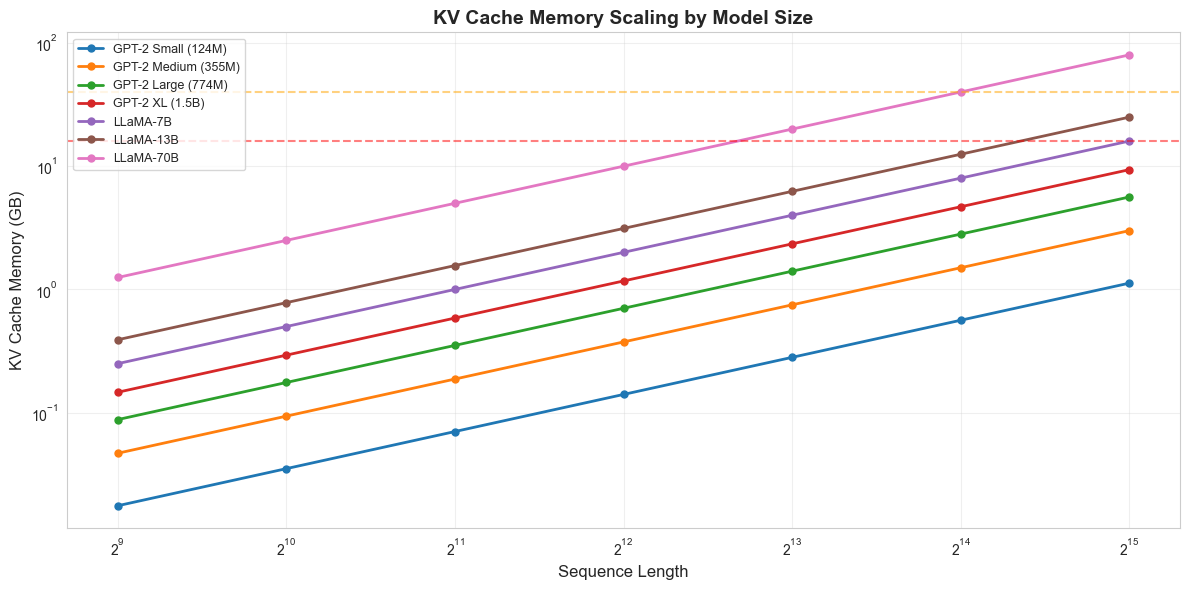


Detailed: LLaMA-7B KV Cache Memory
--------------------------------------------------
  Seq len    512: 0.25 GB
  Seq len   1024: 0.50 GB
  Seq len   2048: 1.00 GB
  Seq len   4096: 2.00 GB
  Seq len   8192: 4.00 GB
  Seq len  16384: 8.00 GB
  Seq len  32768: 16.00 GB


In [34]:
def calculate_kv_cache_memory(n_layers, n_heads, d_k, seq_len, batch_size=1, dtype_bytes=2):
    """
    Calculate KV cache memory in bytes.
    
    Args:
        dtype_bytes: 2 for fp16/bf16, 4 for fp32
    """
    # K and V each: (batch, n_heads, seq_len, d_k)
    k_memory = batch_size * n_heads * seq_len * d_k * dtype_bytes
    v_memory = k_memory  # Same size
    
    # Per layer
    per_layer = k_memory + v_memory
    
    # Total
    total = per_layer * n_layers
    return total

# Example for different model sizes
model_configs = {
    'GPT-2 Small (124M)': {'n_layers': 12, 'n_heads': 12, 'd_k': 64},
    'GPT-2 Medium (355M)': {'n_layers': 24, 'n_heads': 16, 'd_k': 64},
    'GPT-2 Large (774M)': {'n_layers': 36, 'n_heads': 20, 'd_k': 64},
    'GPT-2 XL (1.5B)': {'n_layers': 48, 'n_heads': 25, 'd_k': 64},
    'LLaMA-7B': {'n_layers': 32, 'n_heads': 32, 'd_k': 128},
    'LLaMA-13B': {'n_layers': 40, 'n_heads': 40, 'd_k': 128},
    'LLaMA-70B': {'n_layers': 80, 'n_heads': 64, 'd_k': 128},
}

seq_lengths = [512, 1024, 2048, 4096, 8192, 16384, 32768]

print("KV Cache Memory Requirements (fp16, batch_size=1)")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 6))

for model_name, config in model_configs.items():
    memories_gb = []
    for seq_len in seq_lengths:
        mem = calculate_kv_cache_memory(
            config['n_layers'], config['n_heads'], config['d_k'],
            seq_len, batch_size=1, dtype_bytes=2
        )
        memories_gb.append(mem / (1024**3))  # Convert to GB
    
    ax.plot(seq_lengths, memories_gb, 'o-', label=model_name, linewidth=2, markersize=5)

ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('KV Cache Memory (GB)', fontsize=12)
ax.set_title('KV Cache Memory Scaling by Model Size', fontsize=14, fontweight='bold')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# Add reference lines for common GPU memory sizes
ax.axhline(y=16, color='red', linestyle='--', alpha=0.5, label='16 GB (A100-40GB budget)')
ax.axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='40 GB (A100 memory)')

plt.tight_layout()
plt.show()

# Print table for LLaMA-7B
print("\nDetailed: LLaMA-7B KV Cache Memory")
print("-" * 50)
config = model_configs['LLaMA-7B']
for seq_len in seq_lengths:
    mem = calculate_kv_cache_memory(
        config['n_layers'], config['n_heads'], config['d_k'],
        seq_len, batch_size=1, dtype_bytes=2
    )
    print(f"  Seq len {seq_len:>6}: {mem / (1024**3):.2f} GB")


## Part 6: Reducing KV Cache Size

### Multi-Query Attention (MQA) and Grouped-Query Attention (GQA)

The KV cache can become a memory bottleneck, especially for:
- Long sequences
- Large batch sizes
- Large models

Two techniques reduce KV cache memory:

| Technique | Description | Memory Reduction |
|-----------|-------------|-----------------|
| **Multi-Query Attention (MQA)** | All heads share one K, V | $H \times$ reduction |
| **Grouped-Query Attention (GQA)** | Groups of heads share K, V | $H/G \times$ reduction |

MQA was introduced by Shazeer (2019). GQA (Ainslie et al., 2023) is a middle ground between MQA and standard MHA.


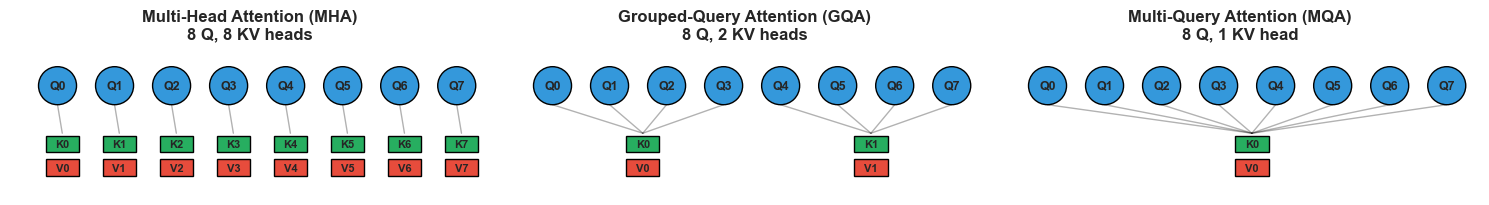


KV Cache Memory Comparison (relative to MHA):
--------------------------------------------------
MHA:  8 KV heads -> 1.00x memory
GQA:  2 KV heads -> 0.25x memory (4x reduction)
MQA:  1 KV head  -> 0.12x memory (8x reduction)


In [37]:
# Visualize MHA vs MQA vs GQA
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n_heads = 8
n_kv_heads_gqa = 2  # GQA groups

# Helper to draw attention head diagram
def draw_attention_diagram(ax, n_q_heads, n_kv_heads, title):
    # Draw Q heads
    for i in range(n_q_heads):
        circle = plt.Circle((i * 1.2 + 0.5, 2), 0.4, color='#3498db', ec='black')
        ax.add_patch(circle)
        ax.text(i * 1.2 + 0.5, 2, f'Q{i}', ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Draw KV heads
    kv_spacing = (n_q_heads * 1.2) / n_kv_heads
    for i in range(n_kv_heads):
        x_pos = i * kv_spacing + kv_spacing / 2
        # K
        rect_k = plt.Rectangle((x_pos - 0.35, 0.6), 0.7, 0.35, color='#27ae60', ec='black')
        ax.add_patch(rect_k)
        ax.text(x_pos, 0.77, f'K{i}', ha='center', va='center', fontsize=8, fontweight='bold')
        # V
        rect_v = plt.Rectangle((x_pos - 0.35, 0.1), 0.7, 0.35, color='#e74c3c', ec='black')
        ax.add_patch(rect_v)
        ax.text(x_pos, 0.27, f'V{i}', ha='center', va='center', fontsize=8, fontweight='bold')
    
    # Draw connections
    heads_per_kv = n_q_heads // n_kv_heads
    for i in range(n_q_heads):
        kv_idx = i // heads_per_kv
        x_q = i * 1.2 + 0.5
        x_kv = kv_idx * kv_spacing + kv_spacing / 2
        ax.plot([x_q, x_kv], [1.6, 1.0], 'k-', alpha=0.3, linewidth=1)
    
    ax.set_xlim(-0.5, n_q_heads * 1.2)
    ax.set_ylim(-0.3, 2.7)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

# MHA: Each head has its own K, V
draw_attention_diagram(axes[0], n_heads, n_heads, f'Multi-Head Attention (MHA)\n{n_heads} Q, {n_heads} KV heads')

# GQA: Groups share K, V
draw_attention_diagram(axes[1], n_heads, n_kv_heads_gqa, f'Grouped-Query Attention (GQA)\n{n_heads} Q, {n_kv_heads_gqa} KV heads')

# MQA: All heads share single K, V
draw_attention_diagram(axes[2], n_heads, 1, f'Multi-Query Attention (MQA)\n{n_heads} Q, 1 KV head')

plt.tight_layout()
plt.show()

# Memory comparison
print("\nKV Cache Memory Comparison (relative to MHA):")
print("-" * 50)
print(f"MHA:  {n_heads} KV heads -> 1.00x memory")
print(f"GQA:  {n_kv_heads_gqa} KV heads -> {n_kv_heads_gqa/n_heads:.2f}x memory ({n_heads//n_kv_heads_gqa}x reduction)")
print(f"MQA:  1 KV head  -> {1/n_heads:.2f}x memory ({n_heads}x reduction)")


## Part 7: Using KV Caching in Practice

### Hugging Face Transformers

The Hugging Face transformers library automatically uses KV caching during generation:

```python
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained("gpt2")
tokenizer = AutoTokenizer.from_pretrained("gpt2")

# KV caching is enabled by default in generate()
outputs = model.generate(
    input_ids,
    max_new_tokens=50,
    use_cache=True  # This is the default
)

# To disable caching (not recommended for inference):
outputs = model.generate(
    input_ids,
    max_new_tokens=50,
    use_cache=False
)
```


### Advanced KV Cache Techniques

| Technique | Description | Use Case |
|-----------|-------------|----------|
| **Paged Attention** | Virtual memory for KV cache | High-throughput serving (vLLM) |
| **Sliding Window** | Only cache recent N tokens | Very long sequences |
| **Quantized Cache** | Store KV in int8/int4 | Memory-constrained deployment |
| **Prompt Caching** | Reuse KV cache across requests | Shared system prompts |

### vLLM and PagedAttention

vLLM uses PagedAttention to efficiently manage KV cache memory:

```python
from vllm import LLM, SamplingParams

llm = LLM(model="meta-llama/Llama-2-7b-hf")
sampling_params = SamplingParams(max_tokens=100)

# vLLM automatically manages KV cache with paging
outputs = llm.generate(prompts, sampling_params)
```


## Summary

### Key Takeaways

1. **The Problem**: Naive autoregressive generation recomputes attention for all previous tokens at every step, leading to O(N^2) complexity per generated token.

2. **KV Caching Solution**: Store K and V tensors from previous tokens and reuse them. Only compute K, V for the new token.

3. **Two Phases**:
   - **Prefill**: Process the entire prompt, building the initial cache
   - **Decode**: Generate tokens one at a time, updating the cache incrementally

4. **Speedup**: KV caching provides significant speedup, especially for long generations:
   - Converts O(N^2) per token to O(N) per token
   - Real-world speedups of 2-10x are common

5. **Memory Trade-off**: KV cache requires memory proportional to:
   - `2 x layers x heads x seq_len x head_dim x batch_size`
   - For large models with long sequences, this can be several GB

6. **Memory Reduction Techniques**:
   - **GQA/MQA**: Reduce KV heads to save memory
   - **Quantization**: Store cache in lower precision
   - **PagedAttention**: Efficient memory management (vLLM)

### Further Reading

- [Multi-Query Attention Paper](https://arxiv.org/abs/1911.02150) (Shazeer, 2019)
- [GQA Paper](https://arxiv.org/abs/2305.13245) (Ainslie et al., 2023)
- [vLLM and PagedAttention](https://arxiv.org/abs/2309.06180) (Kwon et al., 2023)
- [LLM Inference Optimization Survey](https://arxiv.org/abs/2404.14294)
